# EDA Overview\n\n전체 계량기 개요 EDA입니다. 메타데이터, anomaly summary/detail CSV를 기준으로 계량기 분포, 경보 분포, 데이터 커버리지를 확인합니다.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path('/home/playdata2/final_pj/energy-platform')
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metadata_path = PROJECT_ROOT / 'config' / 'meter_metadata.json'
summary_path = PROJECT_ROOT / 'outputs' / 'anomaly_results_summary.csv'
detail_path = PROJECT_ROOT / 'outputs' / 'anomaly_results_detail.csv'

metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
summary_df = pd.read_csv(summary_path)
detail_df = pd.read_csv(detail_path, parse_dates=['ts'])
metadata_df = pd.DataFrame([{'meter_urn': k, **v} for k, v in metadata.items()])
metadata_df.head()

,meter_urn,meter_type,energy_type,thermal_mode,anomaly_target,group_name,redundant_pair,description
0,H1.Z20,electric,production,NaN,P,chp,H1.ZE20,CHP 메인
1,H1.ZE20,electric,production,NaN,P,chp,H1.Z20,CHP redundant
2,V.Z84,electric,production,NaN,P,pv,V.ZE84,PV 그룹1&2 메인
3,V.ZE84,electric,production,NaN,P,pv,V.Z84,PV 그룹1&2 redundant
4,H1.Z310,electric,production,NaN,P,pv,NaN,PV 그룹3


## 1. 기초 통계

In [2]:
detail_agg = detail_df.groupby('meter_urn').agg(
    start_ts=('ts', 'min'),
    end_ts=('ts', 'max'),
    row_count=('ts', 'size'),
    warning_count=('ensemble_level', lambda s: (s == 'WARNING').sum()),
    danger_count=('ensemble_level', lambda s: (s == 'DANGER').sum()),
).reset_index()

overview_df = metadata_df.merge(summary_df, on='meter_urn', how='left').merge(detail_agg, on='meter_urn', how='left')
overview_df[['meter_urn','meter_type','group_name','anomaly_target','row_count','warning','danger','error']].head(10)

,meter_urn,meter_type,group_name,anomaly_target,row_count,warning,danger,error
0,H1.Z20,electric,chp,P,52585.0,232.0,0.0,NaN
1,H1.ZE20,electric,chp,P,9519.0,33.0,0.0,NaN
2,V.Z84,electric,pv,P,39529.0,191.0,0.0,NaN
3,V.ZE84,electric,pv,P,9680.0,26.0,0.0,NaN
4,H1.Z310,electric,pv,P,30817.0,123.0,0.0,NaN
5,H2.Z311,electric,pv,P,30841.0,139.0,0.0,NaN
6,H3.Z312,electric,pv,P,30817.0,136.0,0.0,NaN
7,H1.Z16,electric,cooling_central,P,52585.0,228.0,0.0,NaN
8,H1.Z11,electric,cooling_central,P,52585.0,303.0,0.0,NaN
9,H1.Z12,electric,cooling_central,P,52585.0,305.0,0.0,NaN


## 2. 그룹 집계

meter_type
electric    71
thermal      9
weather      1
Name: count, dtype: int64

group_name
server             13
test               10
cooling_thermal     7
distribution        7
transformer         6
pv                  5
cooling_central     5
cooling_local       5
ventilation         4
design_dis          4
office_dis          4
simulation          3
chp                 2
heating_thermal     2
hvac                2
Name: count, dtype: int64

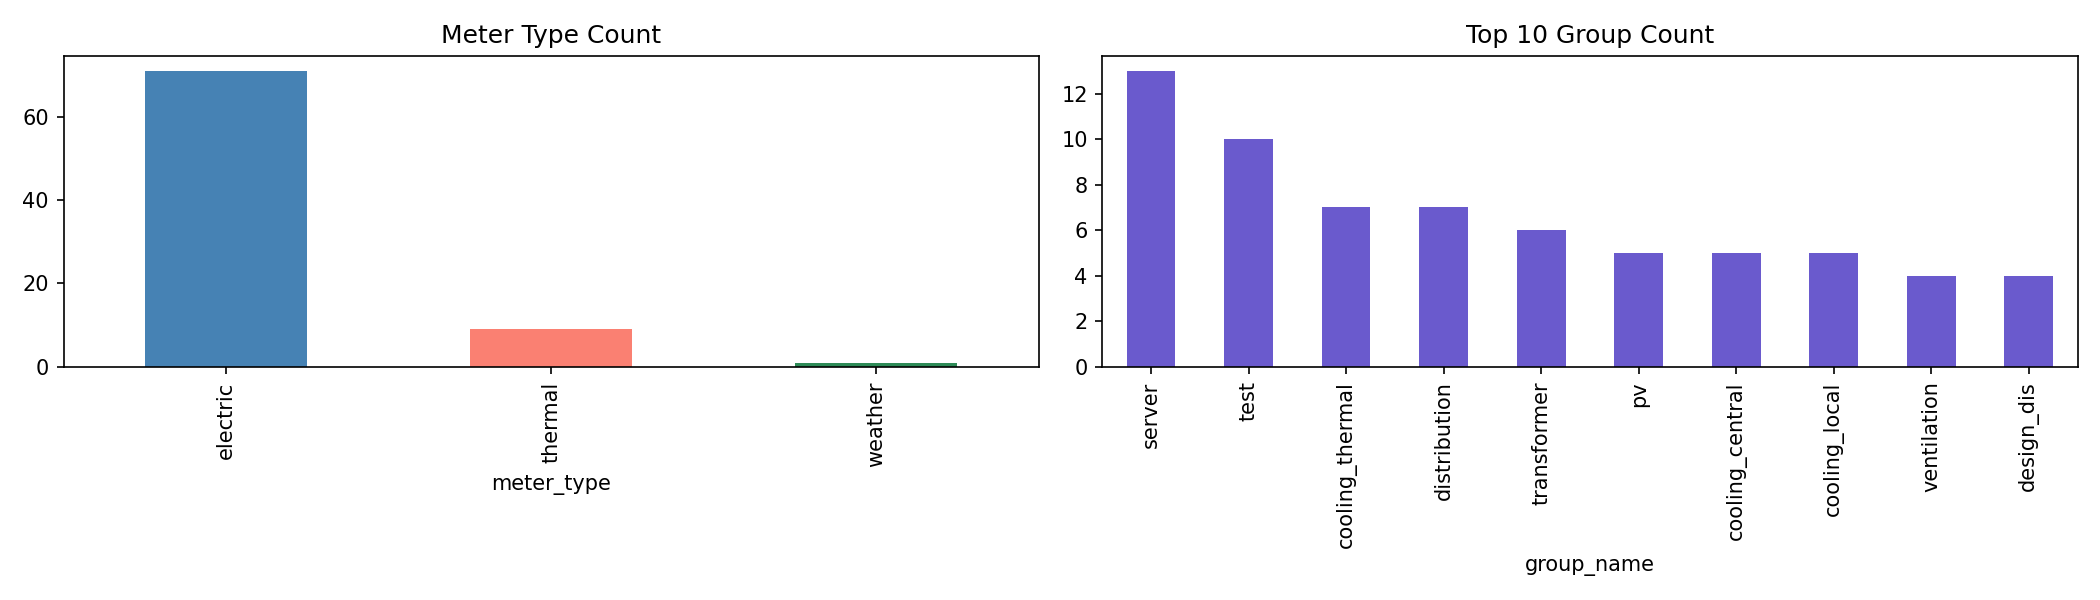

In [3]:
display(metadata_df['meter_type'].value_counts())
display(metadata_df['group_name'].value_counts().head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
metadata_df['meter_type'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon','seagreen'])
axes[0].set_title('Meter Type Count')
metadata_df['group_name'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Top 10 Group Count')
plt.tight_layout()
plot_path = OUTPUT_DIR / 'overview_group_counts.png'
plt.savefig(plot_path, dpi=150)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename=str(plot_path)))


## 3. 이상탐지 요약

In [4]:
top_danger = summary_df.sort_values(['danger', 'warning'], ascending=False)[['meter_urn','danger','warning','danger_pct','warning_pct','error']].head(10)
top_warning = summary_df.sort_values(['warning', 'danger'], ascending=False)[['meter_urn','danger','warning','danger_pct','warning_pct','error']].head(10)
display(top_danger)
display(top_warning)

overview_df.to_csv(OUTPUT_DIR / 'overview_meter_summary.csv', index=False, encoding='utf-8-sig')
print('saved:', OUTPUT_DIR / 'overview_meter_summary.csv')
print('saved:', OUTPUT_DIR / 'overview_group_counts.png')

,meter_urn,danger,warning,danger_pct,warning_pct,error
23,H2.K21,45.0,406.0,0.09,0.77,NaN
24,H1.W11,42.0,360.0,0.08,0.68,NaN
17,V.K21,40.0,246.0,0.08,0.47,NaN
22,H1.K16,21.0,435.0,0.05,0.97,NaN
20,H1.K14,7.0,373.0,0.01,0.71,NaN
18,H1.K11,6.0,391.0,0.01,0.74,NaN
21,H1.K15,5.0,201.0,0.01,0.38,NaN
25,H1.W12,1.0,211.0,0.00,0.40,NaN
43,H1.Z18,0.0,774.0,0.00,1.47,NaN
59,H3.Z46,0.0,602.0,0.00,1.14,NaN


,meter_urn,danger,warning,danger_pct,warning_pct,error
43,H1.Z18,0.0,774.0,0.0,1.47,NaN
59,H3.Z46,0.0,602.0,0.0,1.14,NaN
49,H1.Z27,0.0,585.0,0.0,1.11,NaN
45,H1.Z21,0.0,562.0,0.0,1.07,NaN
32,H1.Z15,0.0,538.0,0.0,1.17,NaN
33,H1.Z28,0.0,532.0,0.0,1.13,NaN
27,V.Z82,0.0,505.0,0.0,1.05,NaN
26,V.Z81,0.0,491.0,0.0,1.11,NaN
42,H1.Z17,0.0,458.0,0.0,0.87,NaN
46,H1.Z22,0.0,437.0,0.0,0.92,NaN


saved: /home/playdata2/final_pj/energy-platform/outputs/eda/overview_meter_summary.csv
saved: /home/playdata2/final_pj/energy-platform/outputs/eda/overview_group_counts.png
